## Day 1 - Train / Validation / Test Split

## Introduction

In this notebook, I will learn how to split a dataset into training, validation, and testing sets.

The validation set will be used during model tuning, while the test set will be kept untouched until the final evaluation.

## Learning Objectives

- Understand why a validation set is needed.
- Create a three-way data split.
- Train and tune a model correctly.
- Evaluate the final model only once on the test set.

## Three-Way Split

| Dataset Split | Purpose | When Used |
|---|---|---|
| Training Set | Train the model | During `.fit()` |
| Validation Set | Tune model choices | During development |
| Test Set | Final honest evaluation | Once at the end |

### Important Note

The test set should not be used during model tuning.

If we repeatedly check the test score while changing the model, the test set starts influencing our decisions and the final score is no longer an honest estimate of performance on new data.

## Import Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## Load Dataset

I will use the Healthcare Stroke Dataset from Week 3 for this exercise.

In [3]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### Observation

The first five rows show patient information such as age, glucose level, BMI, smoking status, and stroke outcome.

The target variable is `stroke`.

## Dataset Overview

In [4]:
print("Dataset shape:",df.shape)

Dataset shape: (5110, 12)


### Observation

The dataset contains 5,110 samples and 12 columns.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


### Observation

The dataset contains both numerical and categorical features.

The `bmi` column contains missing values that will need to be handled before model training.

## Prepare Features and Target

The remaining columns are used as input features, while `stroke` is the target variable.

In [6]:
df = df.drop("id", axis=1)
x = df.drop("stroke", axis=1)
y = df["stroke"]
print("Features shape:", x.shape)
print("Target shape:", y.shape)

Features shape: (5110, 10)
Target shape: (5110,)


he input features are stored in `x`, while the stroke outcome is stored in `y`.

## Hands-On lab :
### Step 1:  create a 60/20/20 train/validation/test split with a fixed random_state

In [7]:
x_temp, x_test, y_temp, y_test = train_test_split(
    x, y,  test_size=0.2,
    random_state=42,
    stratify=y
)

x_train, x_val, y_train, y_val = train_test_split(
    x_temp,y_temp,
    test_size=0.25,
    random_state=42,
    stratify=y_temp
)

In [8]:
print("Training set:", x_train.shape)
print("Validation set:",x_val.shape)
print("Testing set:", x_test.shape)

Training set: (3066, 10)
Validation set: (1022, 10)
Testing set: (1022, 10)


### Observation

The dataset was successfully divided into training, validation, and testing sets.

The training set contains 60% of the data, while the validation and testing sets contain 20% each.

The test set will remain untouched until the final evaluation.

## Handle Missing Values

The BMI mean is calculated from the training set only.

The same training mean is then used to fill missing BMI values in the training, validation, and testing sets.

In [9]:
x_train = x_train.copy()
x_val = x_val.copy()
x_test = x_test.copy()

bmi_m = x_train["bmi"].mean()
x_train["bmi"] = x_train["bmi"].fillna(bmi_m)
x_val["bmi"] = x_val["bmi"].fillna(bmi_m)
x_test["bmi"] = x_test["bmi"].fillna(bmi_m)

In [10]:
print("Train missing values:", x_train.isnull().sum().sum())
print("Validation missing values:", x_val.isnull().sum().sum())
print("Test missing values:", x_test.isnull().sum().sum())

Train missing values: 0
Validation missing values: 0
Test missing values: 0


All missing BMI values were handled successfully.

## Prepare Data for Modeling

The categorical features are converted into numerical values before training the model.

In [11]:
x_train_encoded = pd.get_dummies(x_train, drop_first=True)
x_val_encoded = pd.get_dummies(x_val, drop_first=True)
x_test_encoded = pd.get_dummies(x_test, drop_first=True)

x_train_encoded, x_val_encoded = x_train_encoded.align(
    x_val_encoded,
    join="left",
    axis=1,
    fill_value=0
)

x_train_encoded, x_test_encoded = x_train_encoded.align(
    x_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)

The categorical features were converted into numerical values, and all three datasets now contain the same feature columns.

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_encoded)
x_val_scaled = scaler.transform(x_val_encoded)
x_test_scaled = scaler.transform(x_test_encoded)

The scaler was fitted on the training data only and then applied to the validation and test sets.

### Step 2 :Train a model on the training set and tune one setting by checking the validation set only.

In [13]:
model_1 = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model_1.fit(x_train_scaled, y_train)

val_pred_1 = model_1.predict(x_val_scaled)

f1_model_1 = f1_score(
    y_val,
    val_pred_1
)

print("Validation F1-score for C=1.0:", f1_model_1)

Validation F1-score for C=1.0: 0.24924012158054712


### Observation

The first Logistic Regression model was trained on the training set and evaluated on the validation set.

In [14]:
model_2 = LogisticRegression(
    C=0.1,
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model_2.fit(x_train_scaled, y_train)

val_pred_2 = model_2.predict(x_val_scaled)

f1_model_2 = f1_score(
    y_val,
    val_pred_2
)

print("Validation F1-score for C=0.1:", f1_model_2)

Validation F1-score for C=0.1: 0.24404761904761904


### Observation

The second model used the same training data, but the `C` value was changed from 1.0 to 0.1.

Both models were compared using the validation set only.

In [15]:
validation_r = pd.DataFrame({
    "Model":["Logistic Regression c = 1.0",
        "Logistic Regression c = 0.1"],
        "Validation F1-score": [
        f1_model_1,
        f1_model_2
    ]
})

validation_r


,Model,Validation F1-score
0,Logistic Regression c = 1.0,0.249240
1,Logistic Regression c = 0.1,0.244048


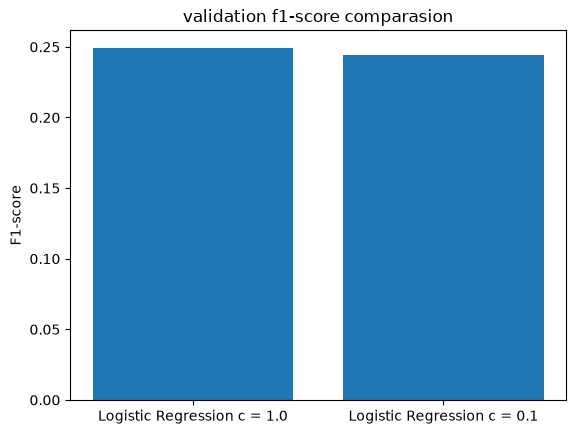

In [16]:
plt.bar(validation_r["Model"],
        validation_r["Validation F1-score"])
plt.ylabel("F1-score")
plt.title("validation f1-score comparasion")
plt.show()

### Observation

Two Logistic Regression models were compared using different values of the `C` hyperparameter.

The model with `C = 1.0` achieved a slightly higher validation F1-score, so it was selected as the final model.

## Step 3: Final Evaluation on the Test Set

After selecting the best model using the validation set, the final evaluation is performed on the test set.

The test set is used only once to provide an unbiased estimate of model performance.

In [17]:
test_prediction = model_1.predict(x_test_scaled)
test_f1 = f1_score(y_test,test_prediction)
print("final test f1-score",test_f1)

final test f1-score 0.24024024024024024


In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, test_prediction))

              precision    recall  f1-score   support

           0       0.99      0.75      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.78      0.55      1022
weighted avg       0.95      0.75      0.82      1022



### Observation

The classification report provides a detailed evaluation of the model using precision, recall, and F1-score for each class.

These metrics help assess the model beyond accuracy

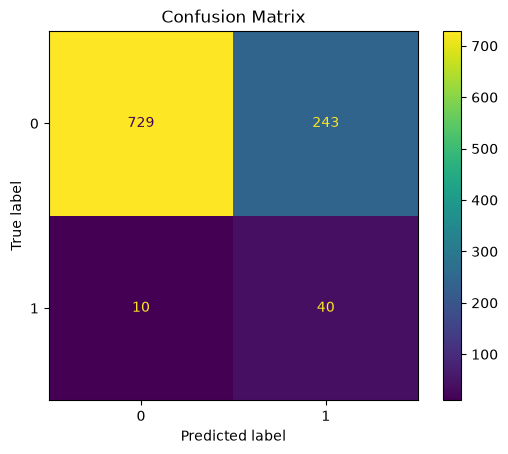

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_prediction
)

plt.title("Confusion Matrix")
plt.show()

### Observation

The confusion matrix shows the number of correct and incorrect predictions for each class.

It helps identify true positives, true negatives, false positives, and false negatives.

## Step 4: Why Should We Not Tune Using the Test Set?

The test set should only be used once after all model tuning has been completed.

If the test set is used during tuning, the model's decisions become influenced by the test data. This causes data leakage and produces an overly optimistic performance estimate.

As a result, the reported score may not reflect the model's true performance on new unseen data.

### Observation

Keeping the test set untouched ensures a fair and unbiased evaluation.

The validation set is the correct choice for comparing models and tuning hyperparameters during development.

# Summary

In this notebook, I:

- Created a three-way data split.
- Handled missing values.
- Encoded categorical features.
- Applied feature scaling.
- Trained two Logistic Regression models.
- Tuned the `C` hyperparameter using the validation set.
- Selected the best model.
- Evaluated the final model on the test set.
- Learned why the test set should remain untouched during tuning.